In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
import warnings
warnings.filterwarnings("ignore")

In [85]:
df = pd.read_csv("LOAN_DATASET.csv")

In [86]:
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22.0,female,Master,71948.0,0.0,RENT,35000.0,PERSONAL,16.02,NaN,3,561.0,No,1
1,21.0,female,High School,12282.0,0.0,OWN,1000.0,EDUCATION,11.14,0.08,2,504.0,Yes,0
2,25.0,female,high school,12438.0,3.0,MORTGAGE,16500.0,MEDICAL,12.87,NaN,3,635.0,No,1
3,23.0,female,Bachelor,67138.0,0.0,RENT,35000.0,MEDICAL,15.23,0.44,2,675.0,No,1
4,24.0,male,Master,NaN,1.0,NaN,NaN,MEDICAL,14.27,0.53,4,586.0,No,1


In [87]:
df.tail()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
45445,23.0,male,Associate,51327.0,0.0,RENT,10000.0,HOMEIMPROVEMENT,15.58,0.19,3,634.0,No,1
45446,31.0,female,Master,24784.0,8.0,OWN,6400.0,VENTURE,5.42,0.26,6,548.0,Yes,0
45447,25.0,male,High School,27710.0,4.0,RENT,3988.0,DEBTCONSOLIDATION,11.34,0.14,4,550.0,No,1
45448,25.0,female,high school,91104.0,6.0,MORTGAGE,15000.0,DEBTCONSOLIDATION,9.78,0.16,4,684.0,Yes,0
45449,30.0,male,High School,87344.0,7.0,MORTGAGE,6532.0,EDUCATION,9.81,0.07,7,663.0,Yes,0


In [88]:
df.sample(5)

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
25798,27.0,female,Associate,81390.0,5.0,RENT,2800.0,DEBTCONSOLIDATION,13.04,0.03,10,690.0,No,0
40439,25.0,female,High School,91204.0,0.0,Rent,7000.0,HOMEIMPROVEMENT,10.43,0.08,4,594.0,yes,0
6847,26.0,male,High School,85326.0,6.0,RENT,6000.0,MEDICAL,6.17,0.07,4,670.0,Yes,0
43303,26.0,male,Associate,60839.0,3.0,RENT,15881.0,VENTURE,16.44,0.26,4,660.0,No,1
4315,24.0,male,Bachelor,48837.0,2.0,MORTGAGE,15000.0,DEBTCONSOLIDATION,9.88,0.31,2,648.0,No,0


In [89]:
df.shape

(45450, 14)

In [90]:
df.columns

Index(['Age ', 'Gender ', 'Education', 'Person Income', 'Employee Experience',
       'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
       'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan',
       'Loan Status'],
      dtype='object')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45450 entries, 0 to 45449
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45450 non-null  float64
 1   Gender               45450 non-null  object 
 2   Education            44820 non-null  object 
 3   Person Income        44449 non-null  float64
 4   Employee Experience  42861 non-null  float64
 5   Home Onwership       44084 non-null  object 
 6   Loan Amount          43780 non-null  float64
 7   Loan Intent          45450 non-null  object 
 8   Loan interest Rate   44541 non-null  float64
 9   Loan percentage      43458 non-null  float64
 10  Credit History       45450 non-null  int64  
 11  Credit Score         44958 non-null  float64
 12  Previous Loan        45450 non-null  object 
 13  Loan Status          45450 non-null  int64  
dtypes: float64(7), int64(2), object(5)
memory usage: 4.9+ MB


In [92]:
df.describe()

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
count,45450.000000,4.444900e+04,42861.000000,43780.000000,44541.000000,43458.000000,45450.000000,44958.000000,45450.000000
mean,27.977580,8.251936e+04,5.440377,9601.742965,11.006889,0.139812,5.864642,633.386701,0.222486
std,7.178325,8.698069e+04,6.300732,6404.766525,2.975369,0.087410,3.878241,51.819423,0.415921
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.838500e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,602.000000,0.000000
50%,26.000000,6.713800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.568200e+04,8.000000,12000.000000,12.990000,0.190000,8.000000,670.000000,0.000000
max,168.000000,7.200766e+06,145.000000,105000.000000,20.000000,0.660000,30.000000,934.700000,1.000000


In [93]:
df.isnull().sum()

Age                       0
Gender                    0
Education               630
Person Income          1001
Employee Experience    2589
Home Onwership         1366
Loan Amount            1670
Loan Intent               0
Loan interest Rate      909
Loan percentage        1992
Credit History            0
Credit Score            492
Previous Loan             0
Loan Status               0
dtype: int64

In [94]:
(df.isnull().sum()/len(df))*100

Age                    0.000000
Gender                 0.000000
Education              1.386139
Person Income          2.202420
Employee Experience    5.696370
Home Onwership         3.005501
Loan Amount            3.674367
Loan Intent            0.000000
Loan interest Rate     2.000000
Loan percentage        4.382838
Credit History         0.000000
Credit Score           1.082508
Previous Loan          0.000000
Loan Status            0.000000
dtype: float64

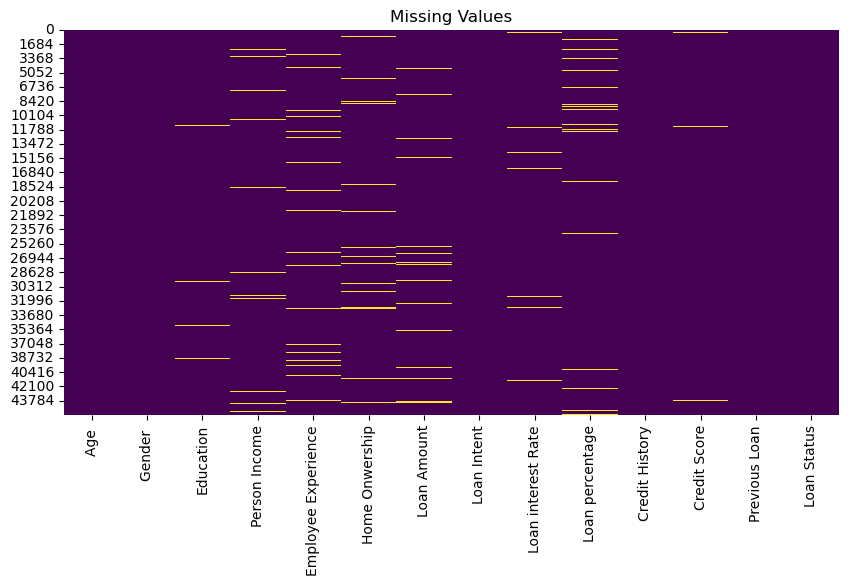

In [95]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values")
plt.show()

In [96]:
df.duplicated().sum()

np.int64(105)

In [97]:
df["Loan Status"].value_counts()

Loan Status
0    35338
1    10112
Name: count, dtype: int64

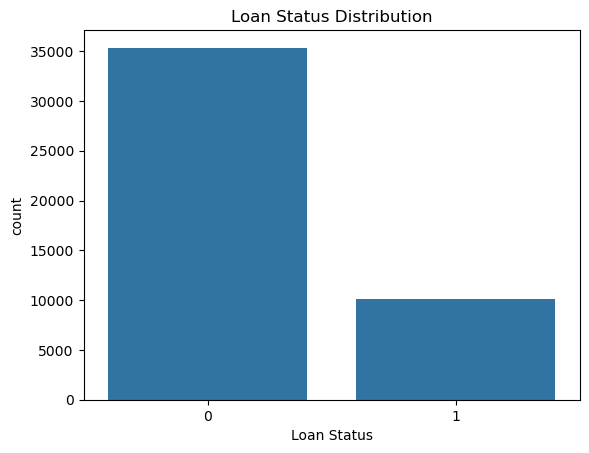

In [98]:
sns.countplot(x="Loan Status", data=df)
plt.title("Loan Status Distribution")
plt.show()

In [99]:
df["Income_per_Experience"] = (
    df["Person Income"] /
    (df["Employee Experience"] + 1)
)

In [100]:
df["Loan_Income_Ratio"] = (
    df["Loan Amount"] /
    df["Person Income"]
)

In [101]:
df["Interest_Burden"] = (
    df["Loan Amount"] *
    df["Loan interest Rate"]
)

In [102]:
df.columns.tolist()

['Age ',
 'Gender ',
 'Education',
 'Person Income',
 'Employee Experience',
 'Home Onwership',
 'Loan Amount',
 'Loan Intent',
 'Loan interest Rate',
 'Loan percentage',
 'Credit History',
 'Credit Score',
 'Previous Loan',
 'Loan Status',
 'Income_per_Experience',
 'Loan_Income_Ratio',
 'Interest_Burden']

In [103]:
numerical = df.select_dtypes(include=['int64','float64']).columns
categorical = df.select_dtypes(include=['object']).columns

In [104]:
print(numerical)
print(categorical)

Index(['Age ', 'Person Income', 'Employee Experience', 'Loan Amount',
       'Loan interest Rate', 'Loan percentage', 'Credit History',
       'Credit Score', 'Loan Status', 'Income_per_Experience',
       'Loan_Income_Ratio', 'Interest_Burden'],
      dtype='object')
Index(['Gender ', 'Education', 'Home Onwership', 'Loan Intent',
       'Previous Loan'],
      dtype='object')


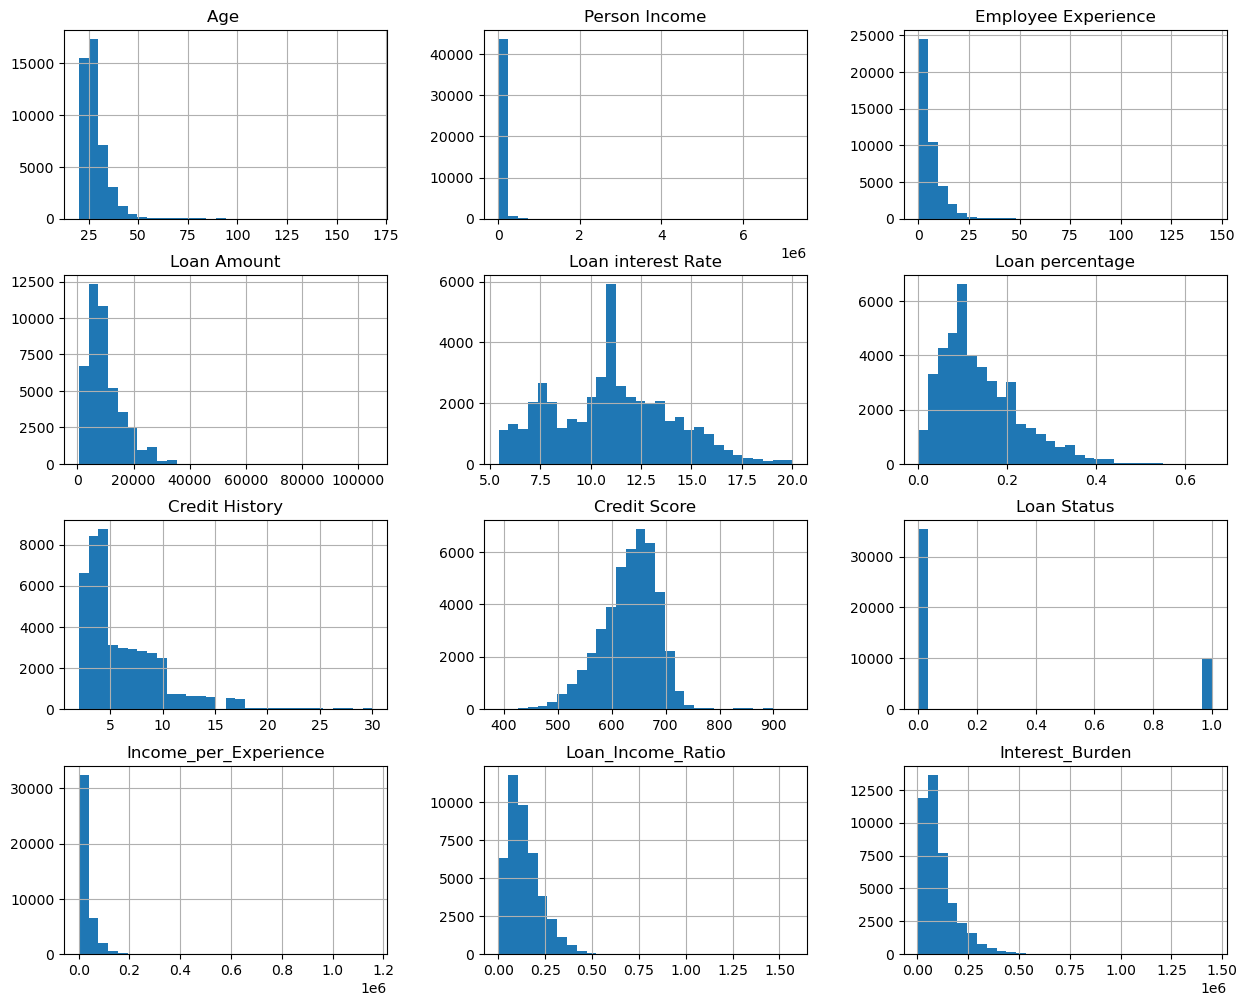

In [105]:
df[numerical].hist(figsize=(15,12), bins=30)
plt.show()

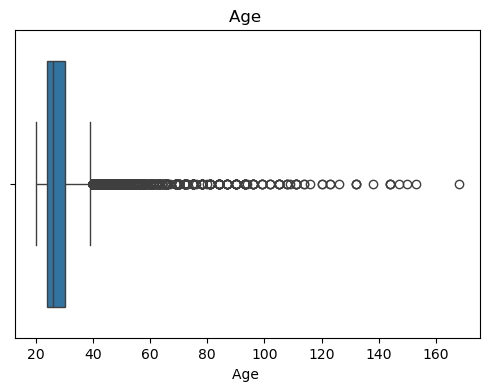

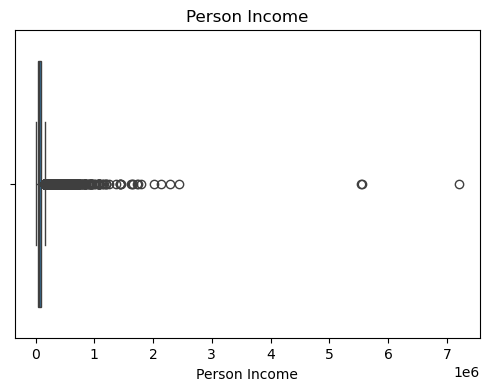

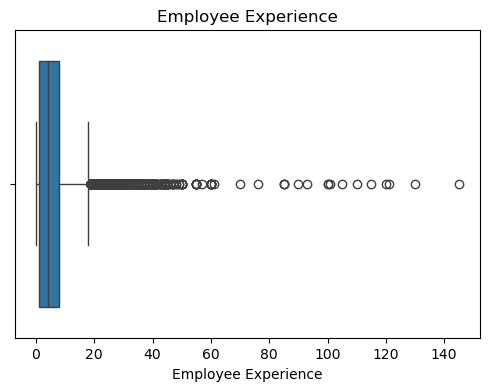

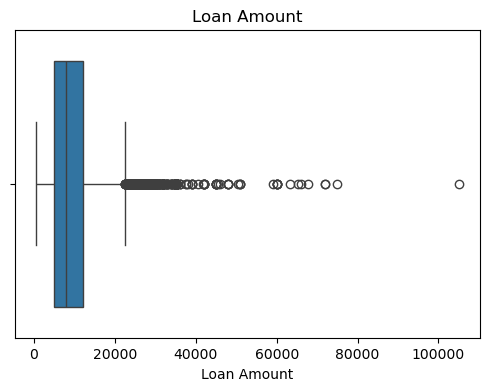

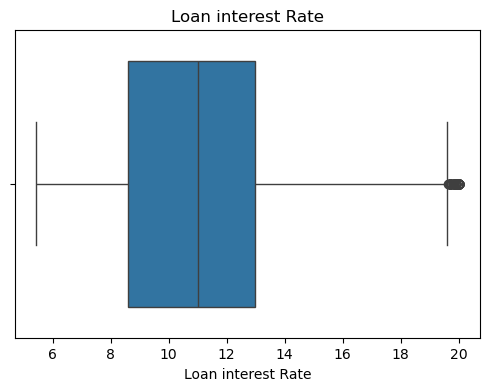

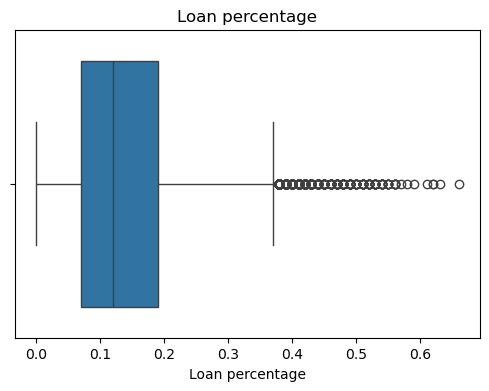

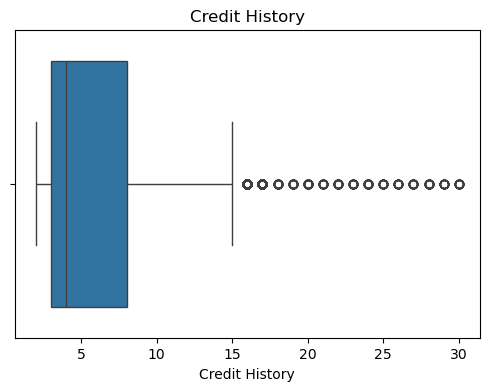

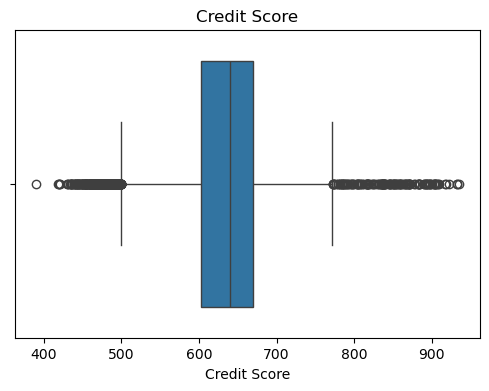

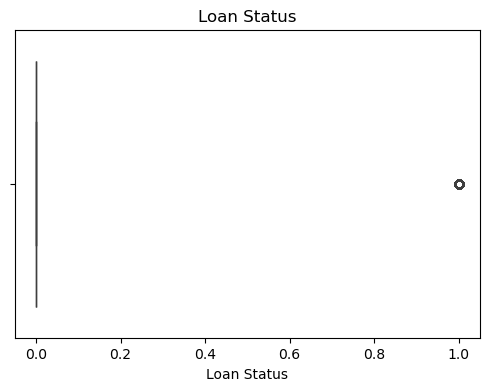

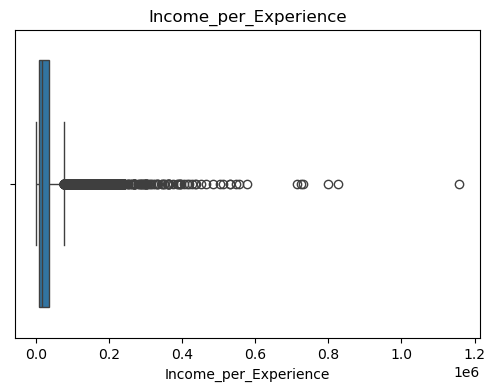

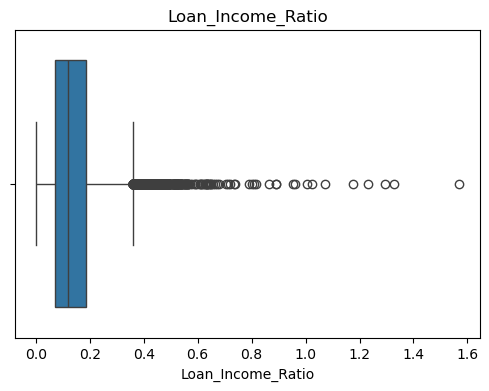

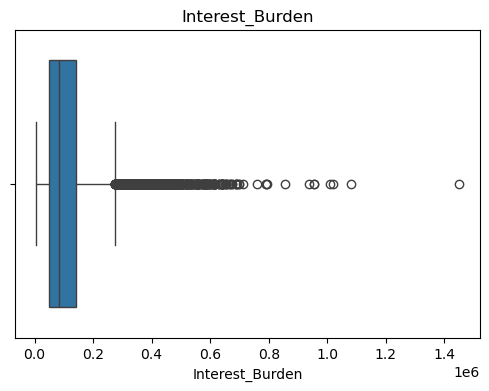

In [106]:
for col in numerical:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

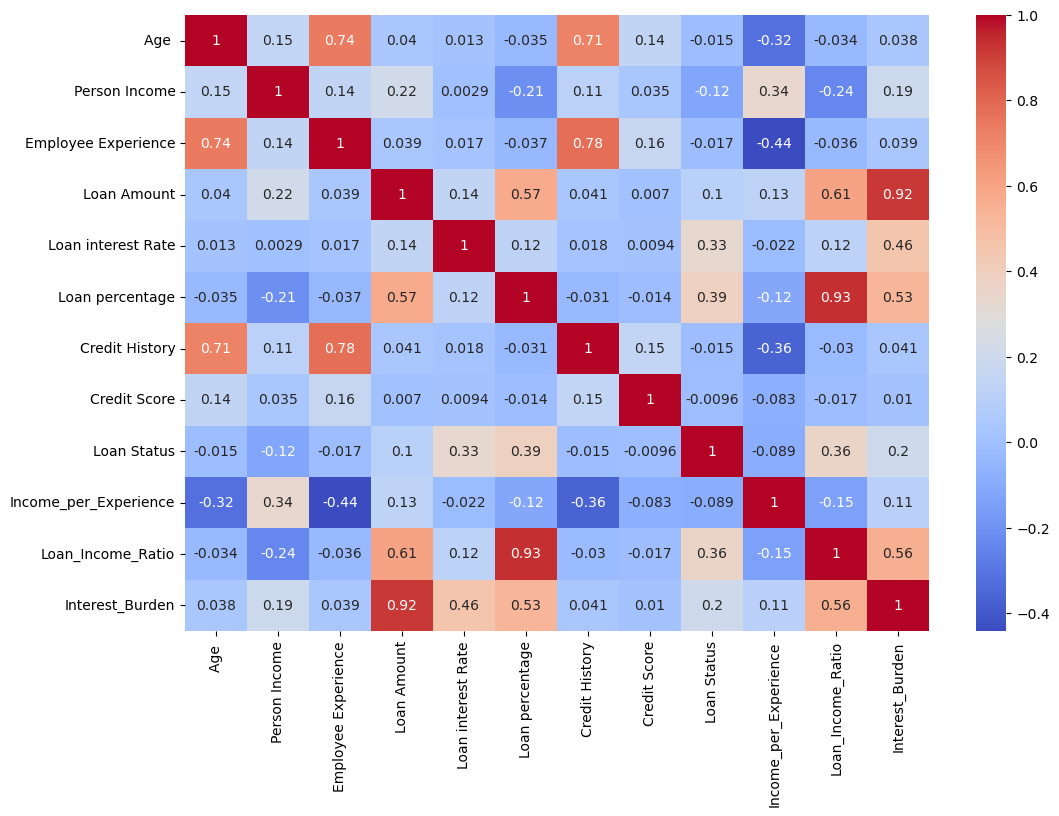

In [107]:
corr = df[numerical].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

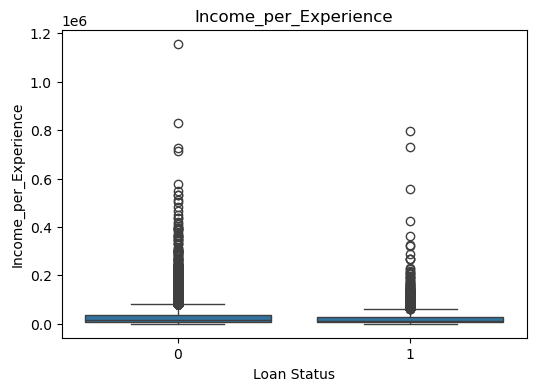

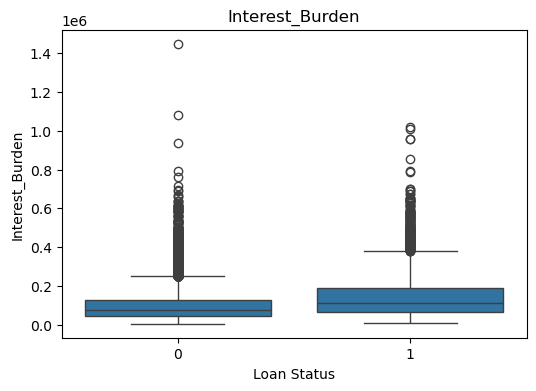

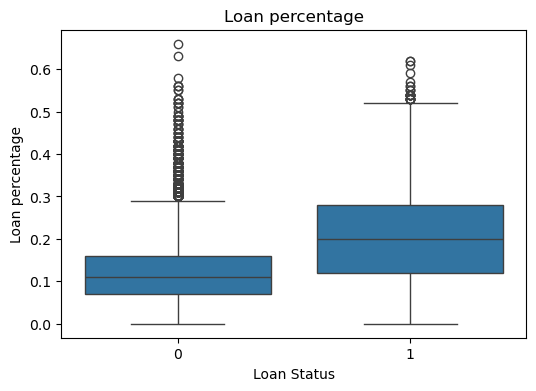

In [108]:
for col in [
    "Income_per_Experience",
    "Interest_Burden",
    "Loan percentage"
]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Loan Status", y=col, data=df)
    plt.title(col)
    plt.show()

In [109]:
df.drop("Loan_Income_Ratio", axis=1, inplace=True)

In [110]:
df.columns = df.columns.str.strip()
df.columns

Index(['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
       'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
       'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan',
       'Loan Status', 'Income_per_Experience', 'Interest_Burden'],
      dtype='object')

In [111]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].str.strip()

In [112]:
for col in cat_cols:
    df[col] = df[col].str.title()

In [113]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].unique())


Gender
['Female' 'Male']

Education
['Master' 'High School' 'Bachelor' 'Associate' nan 'Doctorate']

Home Onwership
['Rent' 'Own' 'Mortgage' nan 'Other']

Loan Intent
['Personal' 'Education' 'Medical' 'Venture' 'Homeimprovement'
 'Debtconsolidation']

Previous Loan
['No' 'Yes']


In [114]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [115]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [116]:
df.isnull().sum()

Age                      0
Gender                   0
Education                0
Person Income            0
Employee Experience      0
Home Onwership           0
Loan Amount              0
Loan Intent              0
Loan interest Rate       0
Loan percentage          0
Credit History           0
Credit Score             0
Previous Loan            0
Loan Status              0
Income_per_Experience    0
Interest_Burden          0
dtype: int64

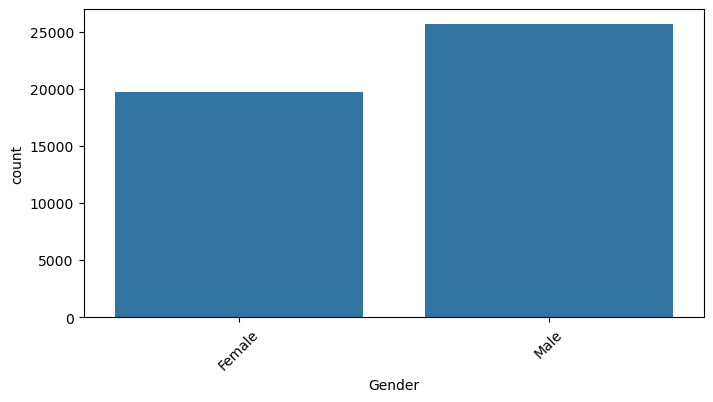

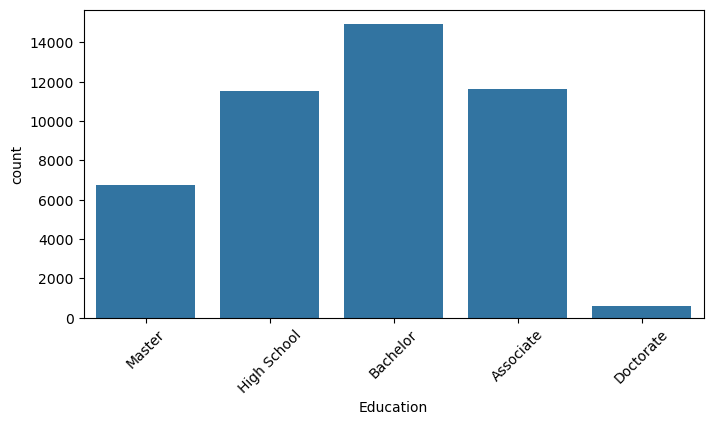

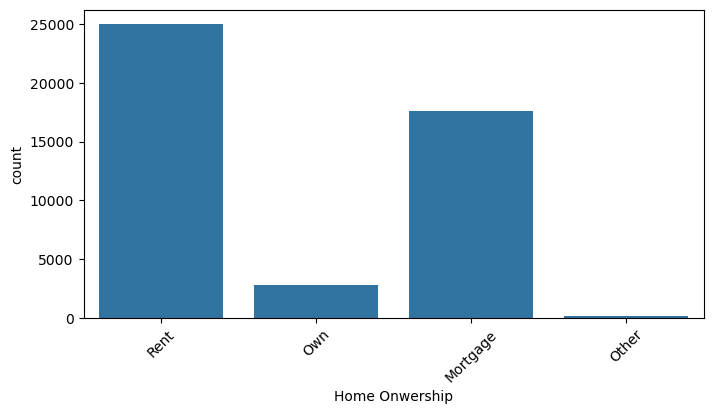

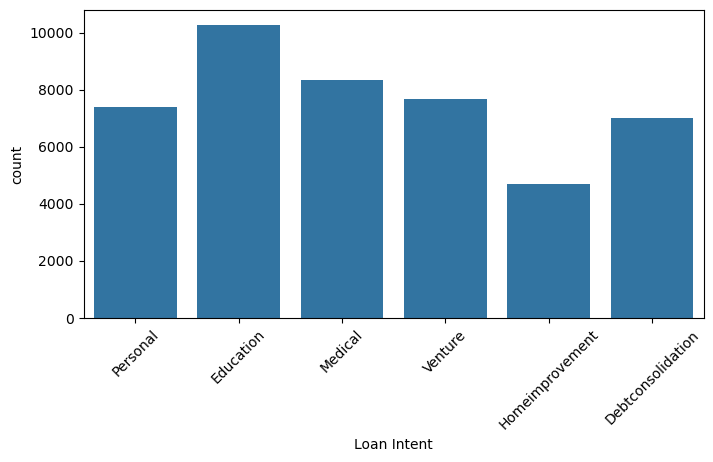

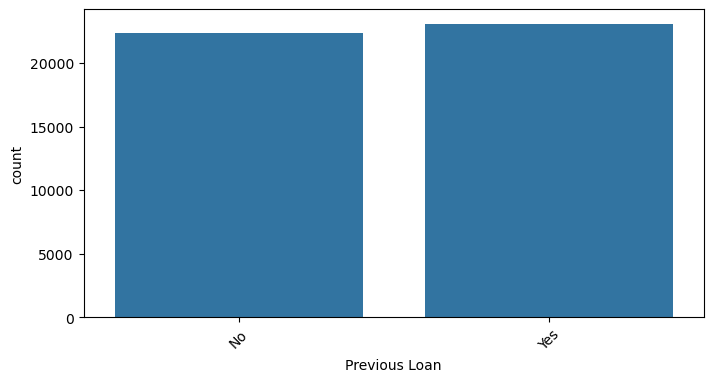

In [117]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col,data=df)
    plt.xticks(rotation=45)
    plt.show()

In [118]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 187


In [119]:
df.drop_duplicates(inplace=True)

In [120]:
print(df.shape)

(45263, 16)


In [121]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing = missing[missing["Missing Values"]>0]

missing.sort_values("Percentage",ascending=False)

,Missing Values,Percentage


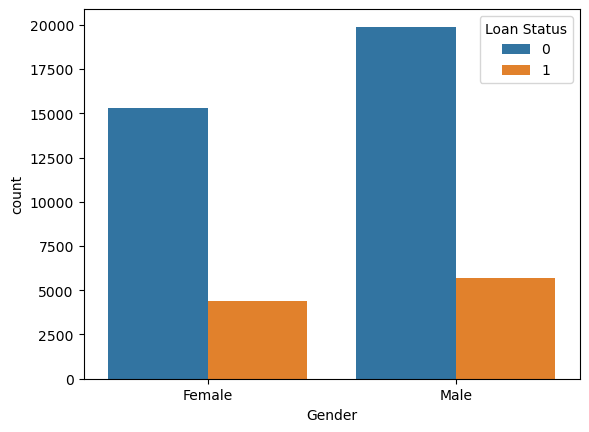

In [122]:
sns.countplot(x="Gender", hue="Loan Status", data=df)
plt.show()

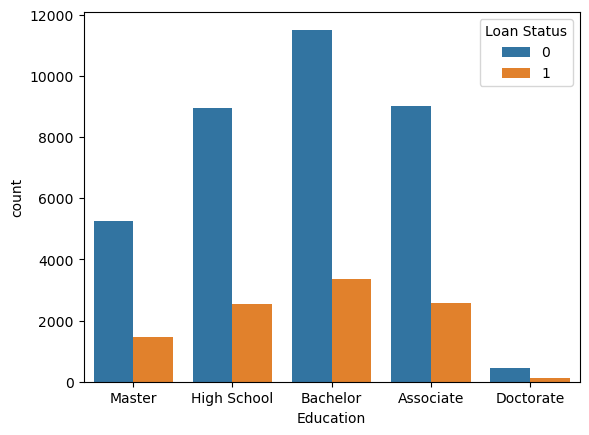

In [123]:
sns.countplot(x="Education", hue="Loan Status", data=df)
plt.show()

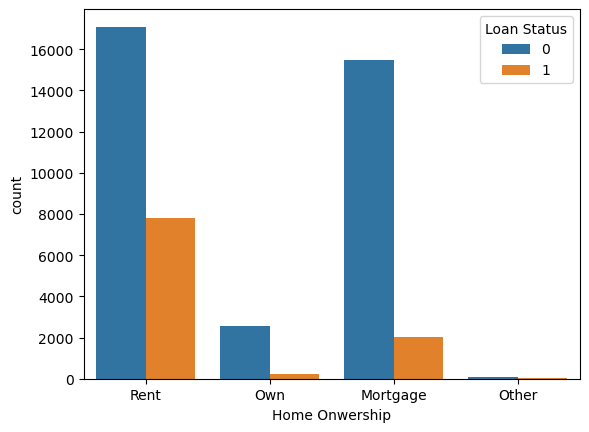

In [124]:
sns.countplot(x="Home Onwership", hue="Loan Status", data=df)
plt.show()

In [125]:
numeric_features = num_cols.drop("Loan Status")

In [126]:
def remove_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = np.where(
        df[column] < lower,
        lower,
        np.where(df[column] > upper, upper, df[column])
    )

    return df

In [127]:
df.columns

Index(['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
       'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
       'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan',
       'Loan Status', 'Income_per_Experience', 'Interest_Burden'],
      dtype='object')

In [128]:
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status,Income_per_Experience,Interest_Burden
0,22.0,Female,Master,71948.0,0.0,Rent,35000.0,Personal,16.02,0.12,3,561.0,No,1,71948.000000,560700.0
1,21.0,Female,High School,12282.0,0.0,Own,1000.0,Education,11.14,0.08,2,504.0,Yes,0,12282.000000,11140.0
2,25.0,Female,High School,12438.0,3.0,Mortgage,16500.0,Medical,12.87,0.12,3,635.0,No,1,3109.500000,212355.0
3,23.0,Female,Bachelor,67138.0,0.0,Rent,35000.0,Medical,15.23,0.44,2,675.0,No,1,67138.000000,533050.0
4,24.0,Male,Master,67138.0,1.0,Rent,8000.0,Medical,14.27,0.53,4,586.0,No,1,15460.733333,83880.0


In [130]:
continuous_cols = [
    "Age",
    "Person Income",
    "Employee Experience",
    "Loan Amount",
    "Loan interest Rate",
    "Loan percentage",
    "Credit History",
    "Credit Score",
    "Income_per_Experience",
    "Interest_Burden"
]

for col in continuous_cols:
    df = remove_outliers(df, col)

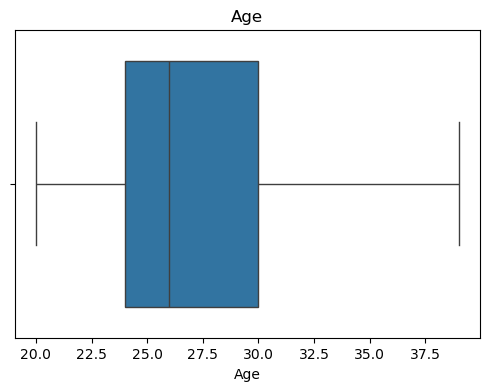

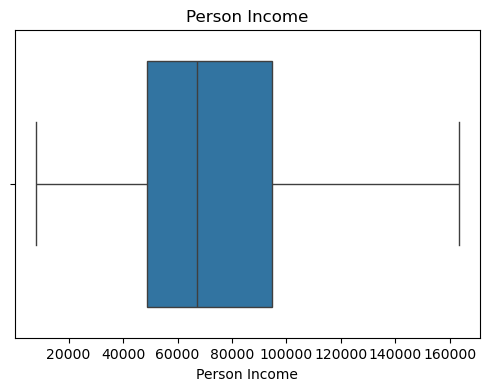

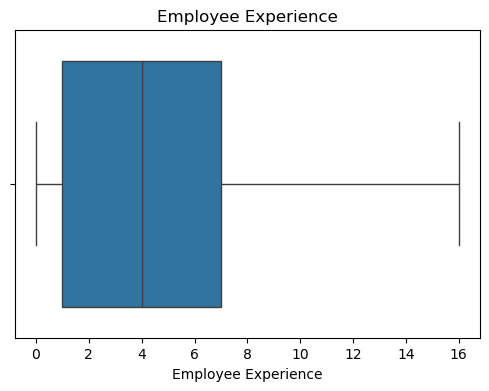

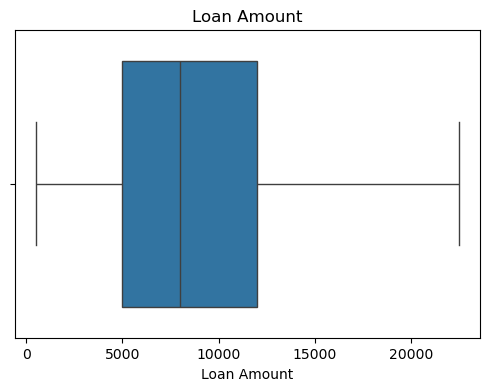

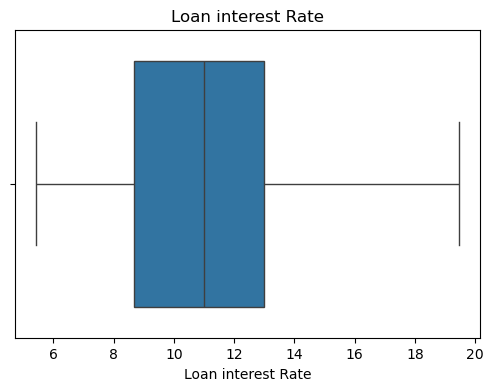

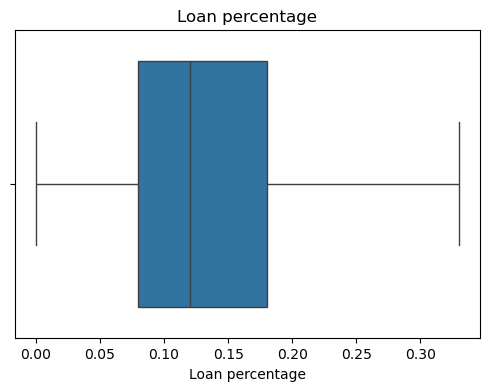

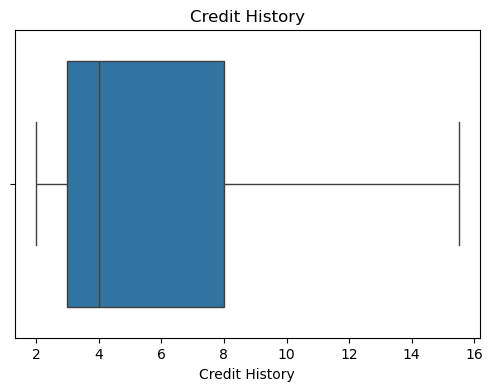

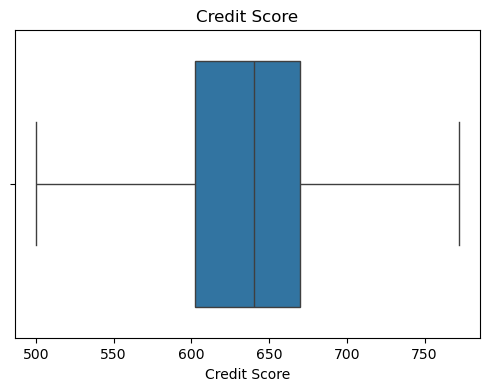

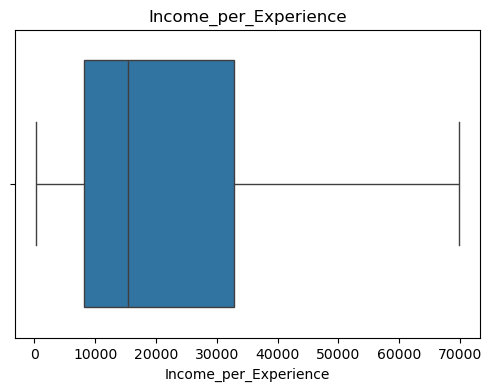

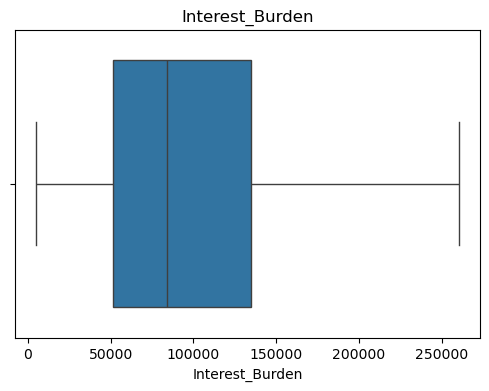

In [131]:
for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [132]:
target = "Loan Status"

num_cols = df.select_dtypes(include=np.number).columns.drop(target)

cat_cols = df.select_dtypes(include="object").columns

print("Numerical Columns")
print(num_cols)

print()

print("Categorical Columns")
print(cat_cols)

Numerical Columns
Index(['Age', 'Person Income', 'Employee Experience', 'Loan Amount',
       'Loan interest Rate', 'Loan percentage', 'Credit History',
       'Credit Score', 'Income_per_Experience', 'Interest_Burden'],
      dtype='object')

Categorical Columns
Index(['Gender', 'Education', 'Home Onwership', 'Loan Intent',
       'Previous Loan'],
      dtype='object')


In [133]:
df["Employee Experience"].min(), df["Employee Experience"].max()

(0.0, 16.0)

In [134]:
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].unique())
    print("-" * 50)

Gender: 2 unique values
['Female' 'Male']
--------------------------------------------------
Education: 5 unique values
['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
--------------------------------------------------
Home Onwership: 4 unique values
['Rent' 'Own' 'Mortgage' 'Other']
--------------------------------------------------
Loan Intent: 6 unique values
['Personal' 'Education' 'Medical' 'Venture' 'Homeimprovement'
 'Debtconsolidation']
--------------------------------------------------
Previous Loan: 2 unique values
['No' 'Yes']
--------------------------------------------------


In [135]:
df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})

df["Previous Loan"] = df["Previous Loan"].map({
    "Yes": 1,
    "No": 0
})

In [136]:
df[["Gender", "Previous Loan"]].head()

,Gender,Previous Loan
0,0,0
1,0,1
2,0,0
3,0,0
4,1,0


In [137]:
df = pd.get_dummies(
    df,
    columns=["Education", "Home Onwership", "Loan Intent"],
    drop_first=True,
    dtype=int
)

In [138]:
df.columns

Index(['Age', 'Gender', 'Person Income', 'Employee Experience', 'Loan Amount',
       'Loan interest Rate', 'Loan percentage', 'Credit History',
       'Credit Score', 'Previous Loan', 'Loan Status', 'Income_per_Experience',
       'Interest_Burden', 'Education_Bachelor', 'Education_Doctorate',
       'Education_High School', 'Education_Master', 'Home Onwership_Other',
       'Home Onwership_Own', 'Home Onwership_Rent', 'Loan Intent_Education',
       'Loan Intent_Homeimprovement', 'Loan Intent_Medical',
       'Loan Intent_Personal', 'Loan Intent_Venture'],
      dtype='object')

In [139]:
df.head()

,Age,Gender,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,...,Education_High School,Education_Master,Home Onwership_Other,Home Onwership_Own,Home Onwership_Rent,Loan Intent_Education,Loan Intent_Homeimprovement,Loan Intent_Medical,Loan Intent_Personal,Loan Intent_Venture
0,22.0,0,71948.0,0.0,22500.0,16.02,0.12,3.0,561.0,0,...,0,1,0,0,1,0,0,0,1,0
1,21.0,0,12282.0,0.0,1000.0,11.14,0.08,2.0,504.0,1,...,1,0,0,1,0,1,0,0,0,0
2,25.0,0,12438.0,3.0,16500.0,12.87,0.12,3.0,635.0,0,...,1,0,0,0,0,0,0,1,0,0
3,23.0,0,67138.0,0.0,22500.0,15.23,0.33,2.0,675.0,0,...,0,0,0,0,1,0,0,1,0,0
4,24.0,1,67138.0,1.0,8000.0,14.27,0.33,4.0,586.0,0,...,0,1,0,0,1,0,0,1,0,0


In [140]:
print(df.shape)

(45263, 25)


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45263 entries, 0 to 45448
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          45263 non-null  float64
 1   Gender                       45263 non-null  int64  
 2   Person Income                45263 non-null  float64
 3   Employee Experience          45263 non-null  float64
 4   Loan Amount                  45263 non-null  float64
 5   Loan interest Rate           45263 non-null  float64
 6   Loan percentage              45263 non-null  float64
 7   Credit History               45263 non-null  float64
 8   Credit Score                 45263 non-null  float64
 9   Previous Loan                45263 non-null  int64  
 10  Loan Status                  45263 non-null  int64  
 11  Income_per_Experience        45263 non-null  float64
 12  Interest_Burden              45263 non-null  float64
 13  Education_Bachelor   

In [143]:
scaler = StandardScaler()
continuous_cols = [
    "Age",
    "Person Income",
    "Employee Experience",
    "Loan Amount",
    "Loan interest Rate",
    "Loan percentage",
    "Credit History",
    "Credit Score",
    "Income_per_Experience",
    "Interest_Burden"
]
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

In [144]:
df.head()

,Age,Gender,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,...,Education_High School,Education_Master,Home Onwership_Other,Home Onwership_Own,Home Onwership_Rent,Loan Intent_Education,Loan Intent_Homeimprovement,Loan Intent_Medical,Loan Intent_Personal,Loan Intent_Venture
0,-1.108981,0,-0.103196,-1.067805,2.350128,1.704162,-0.213268,-0.777347,-1.447833,0,...,0,1,0,0,1,0,0,0,1,0
1,-1.312138,0,-1.707650,-1.067805,-1.484000,0.045705,-0.712229,-1.056734,-2.586864,1,...,1,0,0,1,0,1,0,0,0,0
2,-0.499510,0,-1.703455,-0.424327,1.280139,0.633642,-0.213268,-0.777347,0.030909,0,...,1,0,0,0,0,0,0,1,0,0
3,-0.905824,0,-0.232540,-1.067805,2.350128,1.435683,2.406279,-1.056734,0.830229,0,...,0,0,0,0,1,0,0,1,0,0
4,-0.702667,1,-0.232540,-0.853313,-0.235679,1.109429,2.406279,-0.497960,-0.948258,0,...,0,1,0,0,1,0,0,1,0,0


In [145]:
X = df.drop("Loan Status", axis=1)
y = df["Loan Status"]

In [146]:
print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (45263, 24)
Shape of y : (45263,)


In [147]:
X.head()

,Age,Gender,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,...,Education_High School,Education_Master,Home Onwership_Other,Home Onwership_Own,Home Onwership_Rent,Loan Intent_Education,Loan Intent_Homeimprovement,Loan Intent_Medical,Loan Intent_Personal,Loan Intent_Venture
0,-1.108981,0,-0.103196,-1.067805,2.350128,1.704162,-0.213268,-0.777347,-1.447833,0,...,0,1,0,0,1,0,0,0,1,0
1,-1.312138,0,-1.707650,-1.067805,-1.484000,0.045705,-0.712229,-1.056734,-2.586864,1,...,1,0,0,1,0,1,0,0,0,0
2,-0.499510,0,-1.703455,-0.424327,1.280139,0.633642,-0.213268,-0.777347,0.030909,0,...,1,0,0,0,0,0,0,1,0,0
3,-0.905824,0,-0.232540,-1.067805,2.350128,1.435683,2.406279,-1.056734,0.830229,0,...,0,0,0,0,1,0,0,1,0,0
4,-0.702667,1,-0.232540,-0.853313,-0.235679,1.109429,2.406279,-0.497960,-0.948258,0,...,0,1,0,0,1,0,0,1,0,0


In [148]:
y.head()

0    1
1    0
2    1
3    1
4    1
Name: Loan Status, dtype: int64

In [149]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [150]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (36210, 24)
X_test  : (9053, 24)
y_train : (36210,)
y_test  : (9053,)


In [151]:
print(y_train.value_counts(normalize=True) * 100)

Loan Status
0    77.749241
1    22.250759
Name: proportion, dtype: float64


In [152]:
print(y_test.value_counts(normalize=True) * 100)

Loan Status
0    77.753231
1    22.246769
Name: proportion, dtype: float64


In [153]:
print(df["Loan Status"].value_counts())
print()
print(df["Loan Status"].value_counts(normalize=True) * 100)

Loan Status
0    35192
1    10071
Name: count, dtype: int64

Loan Status
0    77.750039
1    22.249961
Name: proportion, dtype: float64


In [154]:
from imblearn.over_sampling import SMOTE

In [155]:
smote = SMOTE(random_state=42)

In [156]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [157]:
print("Before SMOTE")
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print()
print("After SMOTE")
print("X_train_smote :", X_train_smote.shape)
print("y_train_smote :", y_train_smote.shape)

Before SMOTE
X_train : (36210, 24)
y_train : (36210,)

After SMOTE
X_train_smote : (56306, 24)
y_train_smote : (56306,)


In [158]:
print(y_train.value_counts())

print()

print(y_train.value_counts(normalize=True)*100)

Loan Status
0    28153
1     8057
Name: count, dtype: int64

Loan Status
0    77.749241
1    22.250759
Name: proportion, dtype: float64


In [159]:
print(y_train_smote.value_counts())

print()

print(y_train_smote.value_counts(normalize=True)*100)

Loan Status
0    28153
1    28153
Name: count, dtype: int64

Loan Status
0    50.0
1    50.0
Name: proportion, dtype: float64


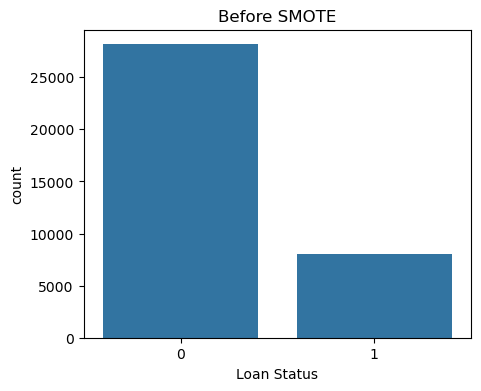

In [160]:
plt.figure(figsize=(5,4))

sns.countplot(x=y_train)

plt.title("Before SMOTE")

plt.show()

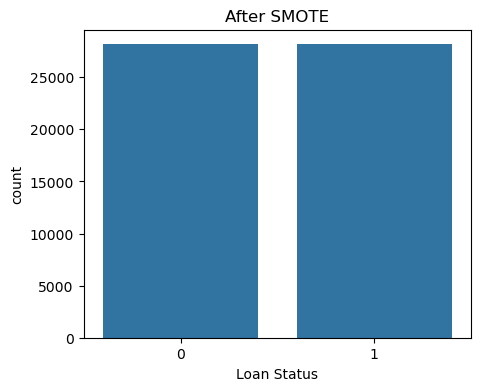

In [161]:
plt.figure(figsize=(5,4))

sns.countplot(x=y_train_smote)

plt.title("After SMOTE")

plt.show()

In [162]:
#MODEL EVALUATIONS

In [163]:
lr = LogisticRegression(random_state=42)

In [164]:
lr.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [165]:
y_pred = lr.predict(X_test)

In [166]:
y_prob = lr.predict_proba(X_test)[:,1]

In [167]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8635811333259693


In [168]:
precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 0.6410720753350235


In [169]:
recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 0.8788480635551142


In [170]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", f1)

F1 Score : 0.7413612565445026


In [171]:
roc = roc_auc_score(y_test, y_prob)

print("ROC AUC :", roc)

ROC AUC : 0.9486562523762841


In [172]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.86      0.91      7039
           1       0.64      0.88      0.74      2014

    accuracy                           0.86      9053
   macro avg       0.80      0.87      0.82      9053
weighted avg       0.89      0.86      0.87      9053



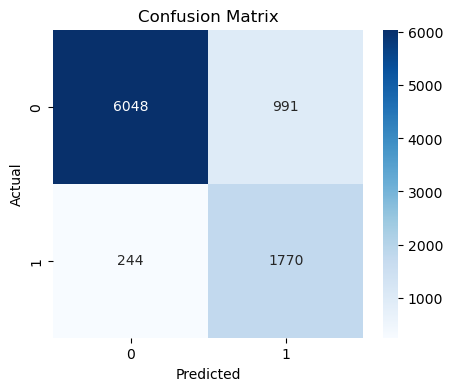

In [173]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [174]:
results = {}

results["Logistic Regression"] = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC AUC": roc
}

In [175]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
auc_lr = roc_auc_score(y_test, y_prob)

In [176]:
#Decision Tree

In [177]:
dt = DecisionTreeClassifier(
    random_state=42
)

In [178]:
dt.fit(X_train_smote, y_train_smote)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [179]:
y_pred_dt = dt.predict(X_test)

In [180]:
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [181]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy :", accuracy_dt)

Accuracy : 0.8813652932729482


In [182]:
precision_dt = precision_score(y_test, y_pred_dt)

print("Precision :", precision_dt)

Precision : 0.7101967799642218


In [183]:
recall_dt = recall_score(y_test, y_pred_dt)

print("Recall :", recall_dt)

Recall : 0.788480635551142


In [184]:
f1_dt = f1_score(y_test, y_pred_dt)

print("F1 Score :", f1_dt)

F1 Score : 0.7472941176470588


In [185]:
roc_dt = roc_auc_score(y_test, y_prob_dt)

print("ROC AUC :", roc_dt)

ROC AUC : 0.8482110522549005


In [186]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92      7039
           1       0.71      0.79      0.75      2014

    accuracy                           0.88      9053
   macro avg       0.82      0.85      0.83      9053
weighted avg       0.89      0.88      0.88      9053



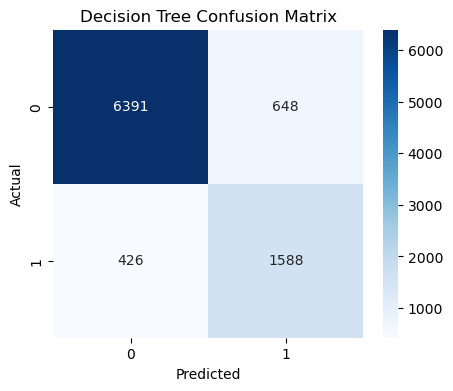

In [187]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [188]:
results["Decision Tree"] = {
    "Accuracy": accuracy_dt,
    "Precision": precision_dt,
    "Recall": recall_dt,
    "F1 Score": f1_dt,
    "ROC AUC": roc_dt
}

In [189]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

In [190]:
#RANDOM FOREST

In [191]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [192]:
rf.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [193]:
y_pred_rf = rf.predict(X_test)

In [194]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [195]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)

Accuracy : 0.9138407157848227


In [196]:
precision_rf = precision_score(y_test, y_pred_rf)

print("Precision :", precision_rf)

Precision : 0.7877798507462687


In [197]:
recall_rf = recall_score(y_test, y_pred_rf)

print("Recall :", recall_rf)

Recall : 0.8386295928500497


In [198]:
f1_rf = f1_score(y_test, y_pred_rf)

print("F1 Score :", f1_rf)

F1 Score : 0.8124098124098124


In [199]:
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC :", roc_rf)

ROC-AUC : 0.9687502865648656


In [200]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      7039
           1       0.79      0.84      0.81      2014

    accuracy                           0.91      9053
   macro avg       0.87      0.89      0.88      9053
weighted avg       0.92      0.91      0.91      9053



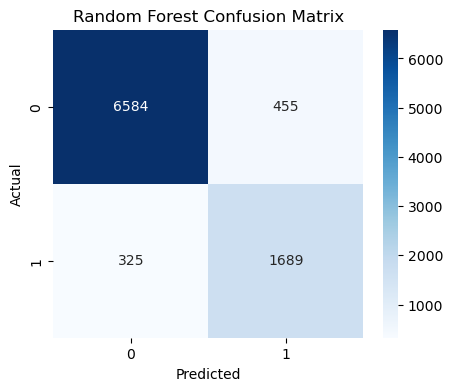

In [201]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [202]:
results["Random Forest"] = {
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1 Score": f1_rf,
    "ROC AUC": roc_rf
}

In [203]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_rf = roc_auc_score(y_test, y_prob_rf)

In [204]:
#KNN

In [205]:
n = len(X_train_smote)
print("Number of training samples:", n)

Number of training samples: 56306


In [206]:
import math
k = int(math.sqrt(n))
print("Initial k:", k)

Initial k: 237


In [207]:
if k % 2 == 0:
    k += 1
print("Final k:", k)

Final k: 237


In [208]:
knn = KNeighborsClassifier(n_neighbors=k)

In [209]:
knn.fit(X_train_smote, y_train_smote)

,n_neighbors,237
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [210]:
y_pred_knn = knn.predict(X_test)

In [211]:
y_prob_knn = knn.predict_proba(X_test)[:, 1]

In [212]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy :", accuracy_knn)

Accuracy : 0.8151993814205236


In [213]:
precision_knn = precision_score(y_test, y_pred_knn)

print("Precision :", precision_knn)

Precision : 0.5518079611060468


In [214]:
recall_knn = recall_score(y_test, y_pred_knn)

print("Recall :", recall_knn)

Recall : 0.9016881827209533


In [215]:
f1_knn = f1_score(y_test, y_pred_knn)

print("F1 Score :", f1_knn)

F1 Score : 0.6846371347785108


In [216]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.97      0.79      0.87      7039
           1       0.55      0.90      0.68      2014

    accuracy                           0.82      9053
   macro avg       0.76      0.85      0.78      9053
weighted avg       0.87      0.82      0.83      9053



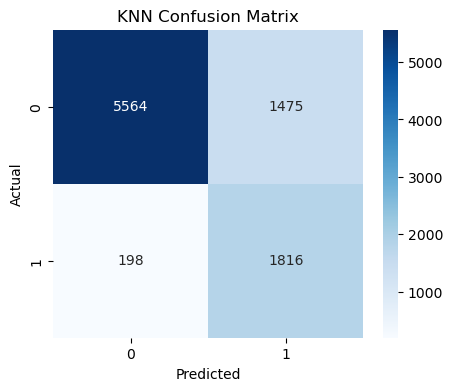

In [217]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [218]:
y_prob_knn = knn.predict_proba(X_test)[:,1]

In [219]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

auc_knn = roc_auc_score(y_test, y_prob_knn)

In [220]:
roc_knn = roc_auc_score(y_test, y_prob_knn)
print("ROC-AUC :", roc_knn)

ROC-AUC : 0.9353354829871818


In [221]:
results["KNN"] = {
    "Accuracy": accuracy_knn,
    "Precision": precision_knn,
    "Recall": recall_knn,
    "F1 Score": f1_knn,
    "ROC AUC": roc_knn
}

In [222]:
from xgboost import XGBClassifier

In [223]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [224]:
xgb.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [225]:
y_pred_xgb = xgb.predict(X_test)

In [226]:
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [227]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("Accuracy :", accuracy_xgb)

Accuracy : 0.9256600022092124


In [228]:
precision_xgb = precision_score(y_test, y_pred_xgb)
print("Precision :", precision_xgb)

Precision : 0.8483116883116883


In [229]:
recall_xgb = recall_score(y_test, y_pred_xgb)

print("Recall :", recall_xgb)

Recall : 0.810824230387289


In [230]:
f1_xgb = f1_score(y_test, y_pred_xgb)

print("F1 Score :", f1_xgb)

F1 Score : 0.8291444529068291


In [231]:
roc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("ROC-AUC :", roc_xgb)

ROC-AUC : 0.9720690075001344


In [232]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      7039
           1       0.85      0.81      0.83      2014

    accuracy                           0.93      9053
   macro avg       0.90      0.88      0.89      9053
weighted avg       0.92      0.93      0.93      9053



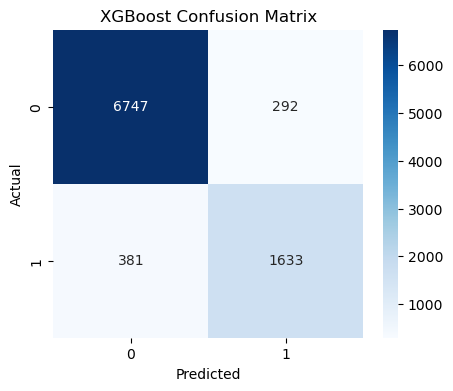

In [233]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [234]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

In [235]:
results["XGBoost"] = {
    "Accuracy": accuracy_xgb,
    "Precision": precision_xgb,
    "Recall": recall_xgb,
    "F1 Score": f1_xgb,
    "ROC AUC": roc_xgb
}

In [236]:
from sklearn.svm import SVC

In [237]:
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

In [238]:
svm.fit(X_train_smote, y_train_smote)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [239]:
y_pred_svm = svm.predict(X_test)

In [240]:
y_prob_svm = svm.predict_proba(X_test)[:, 1]

In [241]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_svm = roc_auc_score(y_test, y_prob_svm)

print("Accuracy :", accuracy_svm)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1 Score :", f1_svm)
print("ROC AUC  :", roc_svm)

Accuracy : 0.8777200927869214
Precision: 0.6690272083488632
Recall   : 0.891261171797418
F1 Score : 0.7643176495635512
ROC AUC  : 0.9542436500400028


In [242]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.97      0.87      0.92      7039
           1       0.67      0.89      0.76      2014

    accuracy                           0.88      9053
   macro avg       0.82      0.88      0.84      9053
weighted avg       0.90      0.88      0.88      9053



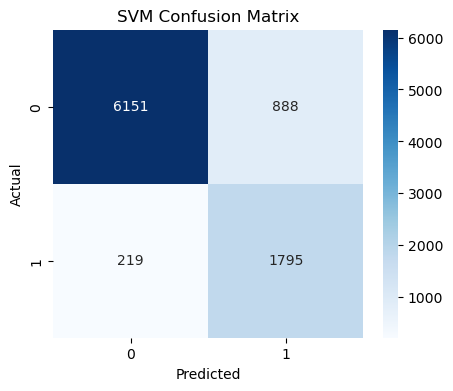

In [243]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

In [244]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

auc_svm = roc_auc_score(y_test, y_prob_svm)

In [245]:
results["SVM"] = {
    "Accuracy": accuracy_svm,
    "Precision": precision_svm,
    "Recall": recall_svm,
    "F1 Score": f1_svm,
    "ROC AUC": roc_svm
}

In [246]:
from sklearn.ensemble import AdaBoostClassifier

In [247]:
adb = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

In [248]:
adb.fit(X_train_smote, y_train_smote)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [249]:
y_pred_adb = adb.predict(X_test)

In [250]:
y_prob_adb = adb.predict_proba(X_test)[:,1]

In [251]:
accuracy_adb = accuracy_score(y_test, y_pred_adb)
precision_adb = precision_score(y_test, y_pred_adb)
recall_adb = recall_score(y_test, y_pred_adb)
f1_adb = f1_score(y_test, y_pred_adb)
roc_adb = roc_auc_score(y_test, y_prob_adb)

print("Accuracy :", accuracy_adb)
print("Precision:", precision_adb)
print("Recall   :", recall_adb)
print("F1 Score :", f1_adb)
print("ROC AUC  :", roc_adb)

Accuracy : 0.8761736440958798
Precision: 0.6649427410417437
Recall   : 0.8937437934458788
F1 Score : 0.7625503071383182
ROC AUC  : 0.9584183622724463


In [252]:
print(classification_report(y_test, y_pred_adb))

              precision    recall  f1-score   support

           0       0.97      0.87      0.92      7039
           1       0.66      0.89      0.76      2014

    accuracy                           0.88      9053
   macro avg       0.82      0.88      0.84      9053
weighted avg       0.90      0.88      0.88      9053



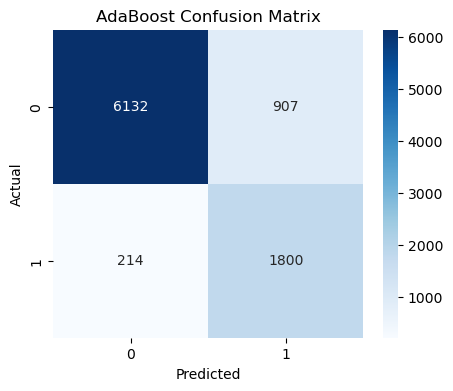

In [253]:
cm = confusion_matrix(y_test, y_pred_adb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("AdaBoost Confusion Matrix")

plt.show()

In [254]:
fpr_adb, tpr_adb, _ = roc_curve(y_test, y_prob_adb)

auc_adb = roc_auc_score(y_test, y_prob_adb)

In [255]:
results["AdaBoost"] = {
    "Accuracy": accuracy_adb,
    "Precision": precision_adb,
    "Recall": recall_adb,
    "F1 Score": f1_adb,
    "ROC AUC": roc_adb
}

In [256]:
results_df = pd.DataFrame(results).T

results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.863581,0.641072,0.878848,0.741361,0.948656
Decision Tree,0.881365,0.710197,0.788481,0.747294,0.848211
Random Forest,0.913841,0.787780,0.838630,0.812410,0.968750
KNN,0.815199,0.551808,0.901688,0.684637,0.935335
XGBoost,0.925660,0.848312,0.810824,0.829144,0.972069
SVM,0.877720,0.669027,0.891261,0.764318,0.954244
AdaBoost,0.876174,0.664943,0.893744,0.762550,0.958418


In [257]:
results_df = results_df.round(4)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.8636,0.6411,0.8788,0.7414,0.9487
Decision Tree,0.8814,0.7102,0.7885,0.7473,0.8482
Random Forest,0.9138,0.7878,0.8386,0.8124,0.9688
KNN,0.8152,0.5518,0.9017,0.6846,0.9353
XGBoost,0.9257,0.8483,0.8108,0.8291,0.9721
SVM,0.8777,0.6690,0.8913,0.7643,0.9542
AdaBoost,0.8762,0.6649,0.8937,0.7626,0.9584


In [258]:
results_df = results_df.sort_values(
    by="Recall",
    ascending=False
)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
KNN,0.8152,0.5518,0.9017,0.6846,0.9353
AdaBoost,0.8762,0.6649,0.8937,0.7626,0.9584
SVM,0.8777,0.6690,0.8913,0.7643,0.9542
Logistic Regression,0.8636,0.6411,0.8788,0.7414,0.9487
Random Forest,0.9138,0.7878,0.8386,0.8124,0.9688
XGBoost,0.9257,0.8483,0.8108,0.8291,0.9721
Decision Tree,0.8814,0.7102,0.7885,0.7473,0.8482


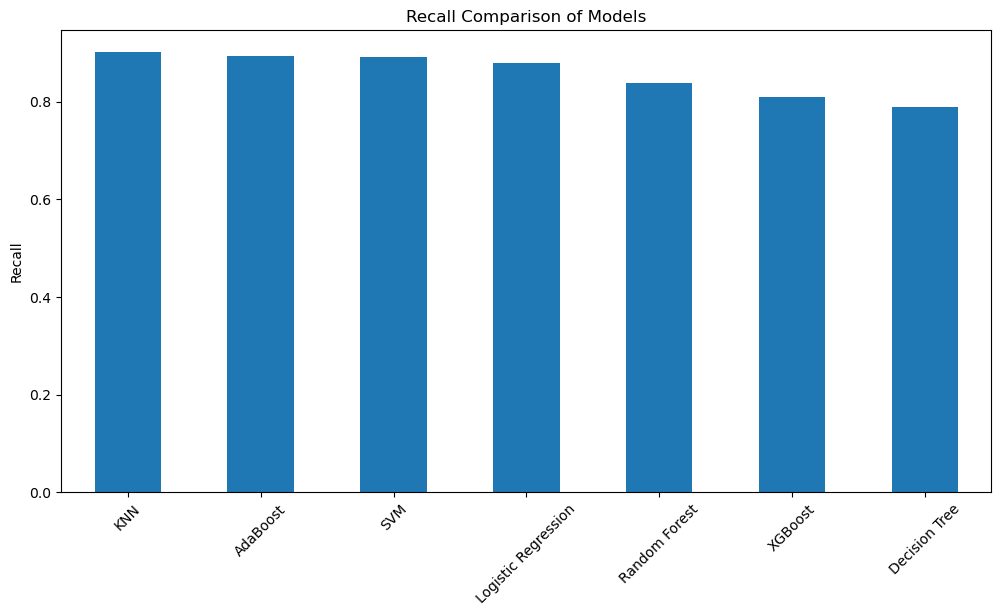

In [259]:
plt.figure(figsize=(12,6))

results_df["Recall"].plot(
    kind="bar"
)

plt.ylabel("Recall")
plt.title("Recall Comparison of Models")
plt.xticks(rotation=45)

plt.show()

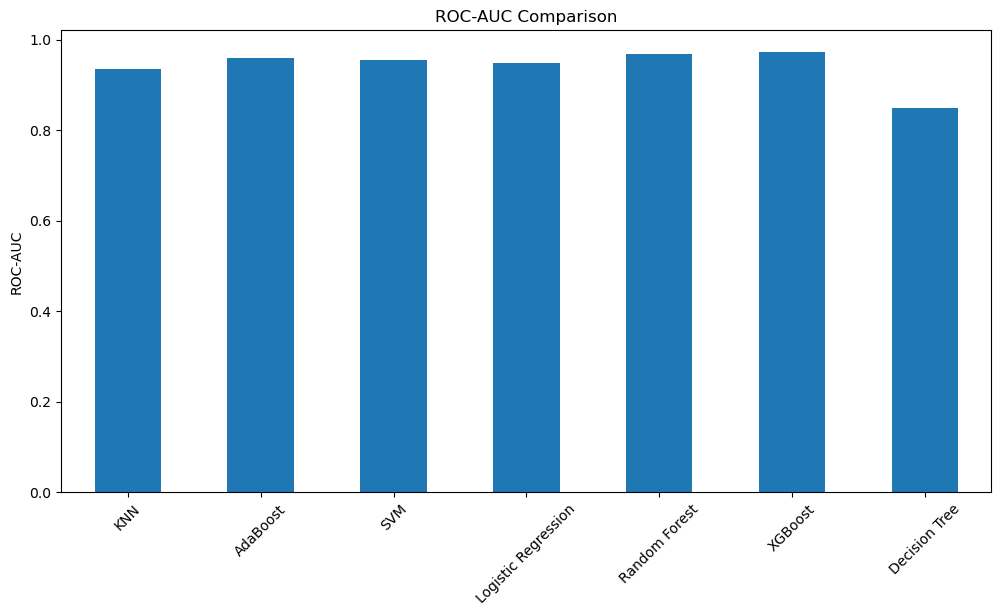

In [260]:
plt.figure(figsize=(12,6))

results_df["ROC AUC"].plot(
    kind="bar"
)

plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison")
plt.xticks(rotation=45)

plt.show()

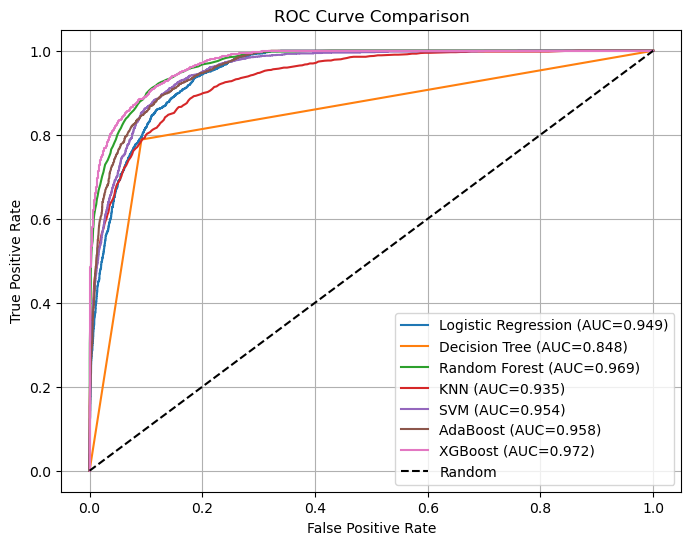

In [261]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc_svm:.3f})")
plt.plot(fpr_adb, tpr_adb, label=f"AdaBoost (AUC={auc_adb:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})")

plt.plot([0,1],[0,1],'k--',label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

In [262]:
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

results_df.sort_values(by="Recall", ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
KNN,0.8152,0.5518,0.9017,0.6846,0.9353
AdaBoost,0.8762,0.6649,0.8937,0.7626,0.9584
SVM,0.8777,0.6690,0.8913,0.7643,0.9542
Logistic Regression,0.8636,0.6411,0.8788,0.7414,0.9487
Random Forest,0.9138,0.7878,0.8386,0.8124,0.9688
XGBoost,0.9257,0.8483,0.8108,0.8291,0.9721
Decision Tree,0.8814,0.7102,0.7885,0.7473,0.8482


In [263]:

results_df.sort_values(by="Recall", ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
KNN,0.8152,0.5518,0.9017,0.6846,0.9353
AdaBoost,0.8762,0.6649,0.8937,0.7626,0.9584
SVM,0.8777,0.6690,0.8913,0.7643,0.9542
Logistic Regression,0.8636,0.6411,0.8788,0.7414,0.9487
Random Forest,0.9138,0.7878,0.8386,0.8124,0.9688
XGBoost,0.9257,0.8483,0.8108,0.8291,0.9721
Decision Tree,0.8814,0.7102,0.7885,0.7473,0.8482


In [269]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=param_dist,
    n_iter=15,          # Try 15 random combinations
    cv=3,               # Faster than 5-fold CV
    scoring="recall",   # Your project objective
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", random_search.best_params_)
print("Best Recall:", random_search.best_score_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best Recall: 0.9349265794046264


In [270]:
best_xgb = random_search.best_estimator_

In [271]:
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

In [272]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned)
recall_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned)
roc_xgb_tuned = roc_auc_score(y_test, y_prob_xgb_tuned)

print(classification_report(y_test, y_pred_xgb_tuned))

print("Accuracy :", accuracy_xgb_tuned)
print("Precision:", precision_xgb_tuned)
print("Recall   :", recall_xgb_tuned)
print("F1 Score :", f1_xgb_tuned)
print("ROC AUC  :", roc_xgb_tuned)

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7039
           1       0.64      0.92      0.76      2014

    accuracy                           0.87      9053
   macro avg       0.81      0.89      0.83      9053
weighted avg       0.90      0.87      0.87      9053

Accuracy : 0.8674472550535735
Precision: 0.6409279778393352
Recall   : 0.9190665342601787
F1 Score : 0.7552019583843329
ROC AUC  : 0.9636319382732578


In [273]:
comparison_xgb = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Before Tuning": [
        accuracy_xgb,
        precision_xgb,
        recall_xgb,
        f1_xgb,
        roc_xgb
    ],
    "After Tuning": [
        accuracy_xgb_tuned,
        precision_xgb_tuned,
        recall_xgb_tuned,
        f1_xgb_tuned,
        roc_xgb_tuned
    ]
})

comparison_xgb

,Metric,Before Tuning,After Tuning
0,Accuracy,0.925660,0.867447
1,Precision,0.848312,0.640928
2,Recall,0.810824,0.919067
3,F1 Score,0.829144,0.755202
4,ROC AUC,0.972069,0.963632


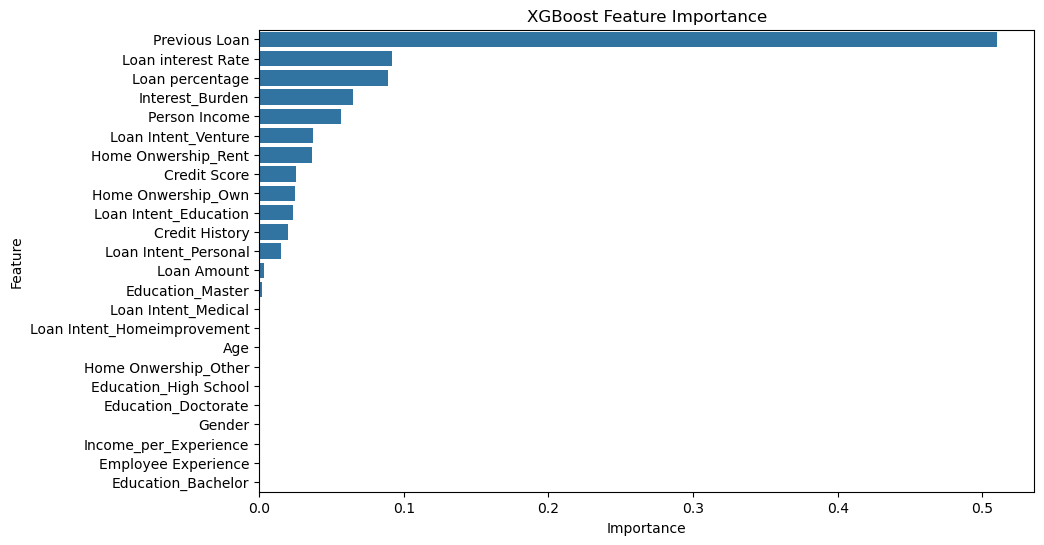

In [274]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("XGBoost Feature Importance")
plt.show()

In [275]:
X.columns.tolist()

['Age',
 'Gender',
 'Person Income',
 'Employee Experience',
 'Loan Amount',
 'Loan interest Rate',
 'Loan percentage',
 'Credit History',
 'Credit Score',
 'Previous Loan',
 'Income_per_Experience',
 'Interest_Burden',
 'Education_Bachelor',
 'Education_Doctorate',
 'Education_High School',
 'Education_Master',
 'Home Onwership_Other',
 'Home Onwership_Own',
 'Home Onwership_Rent',
 'Loan Intent_Education',
 'Loan Intent_Homeimprovement',
 'Loan Intent_Medical',
 'Loan Intent_Personal',
 'Loan Intent_Venture']

In [280]:
import pickle
with open("loan_default_xgboost.pkl", "wb") as file:
    pickle.dump(xgb, file)

In [281]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [282]:
with open("feature_names.pkl", "wb") as file:
    pickle.dump(X.columns.tolist(), file)

In [283]:
#------------------------------------